In [ ]:
Часть 1: Подготовка целевой группы (15%)

In [2]:
#Фильтрация пациентов Оставляем только пациентов с уровнем глюкозы натощак в диапазоне 5.4–6.5 ммоль/л (преддиабет по критериям ADA).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

# Загрузка данных
df = pd.read_csv(r'C:\Users\Name\Documents\ДЗ\Наука о данных в медицине\dispensarization_data_2026.csv')

# Фильтрация
target_group = df[(df['Глюкоза_натощак_ммоль_л'] >= 5.4) & 
                  (df['Глюкоза_натощак_ммоль_л'] <= 6.5)].copy()

print(f"Всего пациентов: {len(df)}")
print(f"Целевая группа (глюкоза 5.4-6.5): {len(target_group)}")
print(f"Процент: {len(target_group)/len(df)*100:.1f}%\n")

Всего пациентов: 1000
Целевая группа (глюкоза 5.4-6.5): 313
Процент: 31.3%



Распределение статусов глюкозы в целевой группе:
Статус_глюкозы
1    150
0     95
2     68
Name: count, dtype: int64


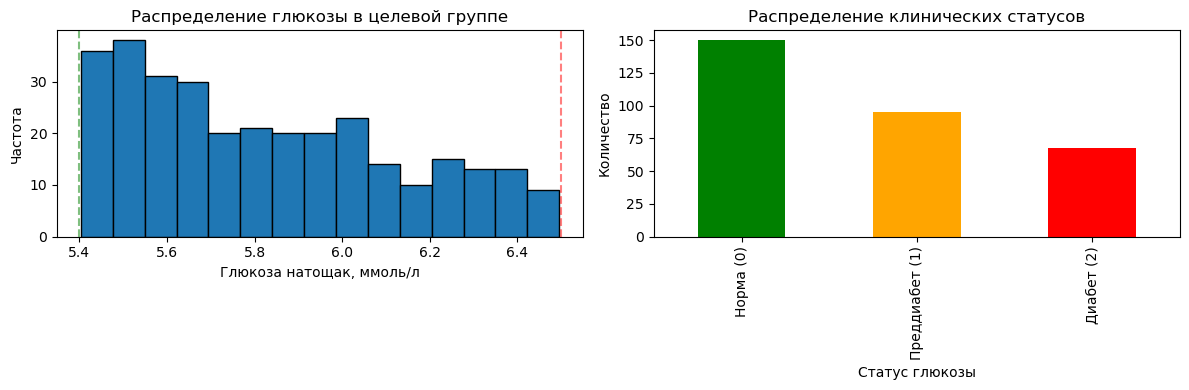


Процент с преддиабетом: 47.9%


In [4]:
#Распределение статусов глюкозы
print("Распределение статусов глюкозы в целевой группе:")
status_counts = target_group['Статус_глюкозы'].value_counts()
print(status_counts)

# Расшифровка: 0=норма, 1=преддиабет, 2=диабет (по данным)
# Построим гистограмму глюкозы по статусам
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма глюкозы
axes[0].hist(target_group['Глюкоза_натощак_ммоль_л'], bins=15, edgecolor='black')
axes[0].set_xlabel('Глюкоза натощак, ммоль/л')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение глюкозы в целевой группе')
axes[0].axvline(5.4, color='g', linestyle='--', alpha=0.5)
axes[0].axvline(6.5, color='r', linestyle='--', alpha=0.5)

# Столбчатая диаграмма статусов
status_counts.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_xlabel('Статус глюкозы')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение клинических статусов')
axes[1].set_xticklabels(['Норма (0)', 'Преддиабет (1)', 'Диабет (2)'])

plt.tight_layout()
plt.show()

print(f"\nПроцент с преддиабетом: {status_counts[1]/len(target_group)*100:.1f}%")

In [5]:
#Выбор 5 признаков для модели. Обоснование выбора клинически значимых признаков:
selected_features = [
    'ИМТ',                                    # Ожирение - ключевой фактор
    'Окружность_талии_см',                  # Центральное ожирение
    'HbA1c_%',                               # Долгосрочный контроль глюкозы
    'САД_мм_рт_ст',                          # Гипертензия - коморбидность
    'Физическая_активность_мин_нед'         # Модифицируемый фактор
]

print("Выбранные признаки:")
for f in selected_features:
    print(f"  • {f}")
    print(f"    Пропуски: {target_group[f].isna().sum()}")
    print(f"    Среднее: {target_group[f].mean():.2f}")

Выбранные признаки:
  • ИМТ
    Пропуски: 0
    Среднее: 25.05
  • Окружность_талии_см
    Пропуски: 0
    Среднее: 88.66
  • HbA1c_%
    Пропуски: 0
    Среднее: 5.12
  • САД_мм_рт_ст
    Пропуски: 0
    Среднее: 117.57
  • Физическая_активность_мин_нед
    Пропуски: 0
    Среднее: 200.97


In [ ]:
Часть 2: Реализация Fuzzy kNN (35%)

In [6]:
#Класс FuzzyKNN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

class FuzzyKNN:
    """
    Нечеткий kNN классификатор с прогнозированием принадлежности к классам
    Параметры: m - коэффициент нечеткости (экспонента)
              k - количество соседей
    """
    
    def __init__(self, k=7, m=2.0):
        self.k = k
        self.m = m
        self.scaler = StandardScaler()
        
    def fit(self, X, y):
        """Обучение: сохраняем обучающие данные и их классы"""
        self.X_train = self.scaler.fit_transform(X)
        self.y_train = y.values if isinstance(y, pd.Series) else y
        self.classes_ = np.unique(self.y_train)
        return self
    
    def _get_neighbors(self, X_test):
        """Находит k ближайших соседей для каждого тестового образца"""
        # Евклидово расстояние
        distances = cdist(X_test, self.X_train, metric='euclidean')
        
        # Получаем индексы k ближайших соседей
        neighbor_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbor_distances = np.sort(distances, axis=1)[:, :self.k]
        
        return neighbor_indices, neighbor_distances
    
    def predict_membership(self, X_test):
        """
        Вычисляет степени принадлежности к каждому классу
        Формула: u_i(x) = Σ (u_ij * (1/d(x,x_j)^(2/(m-1)))) / Σ (1/d(x,x_j)^(2/(m-1)))
        где u_ij - принадлежность соседа к классу i
        """
        X_test_scaled = self.scaler.transform(X_test)
        neighbor_indices, neighbor_distances = self._get_neighbors(X_test_scaled)
        
        # Защита от деления на ноль
        neighbor_distances = np.maximum(neighbor_distances, 1e-10)
        
        # Веса на основе расстояний
        weights = 1.0 / (neighbor_distances ** (2/(self.m - 1)))
        
        memberships = []
        
        for i in range(len(X_test_scaled)):
            # Принадлежности соседей к классам (one-hot encoding)
            neighbor_classes = self.y_train[neighbor_indices[i]]
            neighbor_memberships = np.zeros((self.k, len(self.classes_)))
            
            for j, cls in enumerate(self.classes_):
                neighbor_memberships[:, j] = (neighbor_classes == cls).astype(float)
            
            # Взвешенное суммирование
            weighted_sum = np.sum(neighbor_memberships * weights[i].reshape(-1, 1), axis=0)
            total_weight = np.sum(weights[i])
            
            membership = weighted_sum / total_weight
            memberships.append(membership)
        
        return np.array(memberships)
    
    def predict_risk_score(self, X_test):
        """
        Вычисляет скор риска = membership[преддиабет] * 0.5 + membership[диабет] * 1.0
        Где преддиабет - класс 1, диабет - класс 2
        """
        memberships = self.predict_membership(X_test)
        
        # Индексы классов: 0=норма, 1=преддиабет, 2=диабет
        risk_scores = memberships[:, 1] * 0.5 + memberships[:, 2] * 1.0
        return risk_scores
    
    def predict_hard(self, X_test):
        """Жесткая классификация по максимальной принадлежности"""
        memberships = self.predict_membership(X_test)
        return self.classes_[np.argmax(memberships, axis=1)]

In [8]:
#Подготовка данных и обучение
# Подготовка признаков и целевой переменной
X = target_group[selected_features].copy()
y = target_group['Статус_глюкозы']

# Заполнение пропусков медианой (исправленный способ)
for col in X.columns:
    if X[col].isna().any():
        print(f"Заполняем пропуски в {col}: {X[col].isna().sum()} пропусков")
        # Используем присваивание вместо inplace=True
        X[col] = X[col].fillna(X[col].median())

# Альтернативный вариант - однострочное решение для всех столбцов:
# X = X.fillna(X.median())

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {len(X_train)} пациентов")
print(f"Тестовая выборка: {len(X_test)} пациентов")
print(f"Распределение классов в train: {dict(Counter(y_train))}")
print(f"Распределение классов в test: {dict(Counter(y_test))}")

# Обучение модели
fuzzy_knn = FuzzyKNN(k=7, m=2.0)
fuzzy_knn.fit(X_train, y_train)

# Прогноз
risk_scores = fuzzy_knn.predict_risk_score(X_test)
memberships = fuzzy_knn.predict_membership(X_test)
hard_predictions = fuzzy_knn.predict_hard(X_test)

# Оценка качества
accuracy = np.mean(hard_predictions == y_test)
print(f"\nТочность жесткой классификации: {accuracy:.3f}")

Обучающая выборка: 219 пациентов
Тестовая выборка: 94 пациентов
Распределение классов в train: {2: 48, 1: 105, 0: 66}
Распределение классов в test: {1: 45, 0: 29, 2: 20}

Точность жесткой классификации: 0.436


In [ ]:
Часть 3: Анализ результатов (30%)

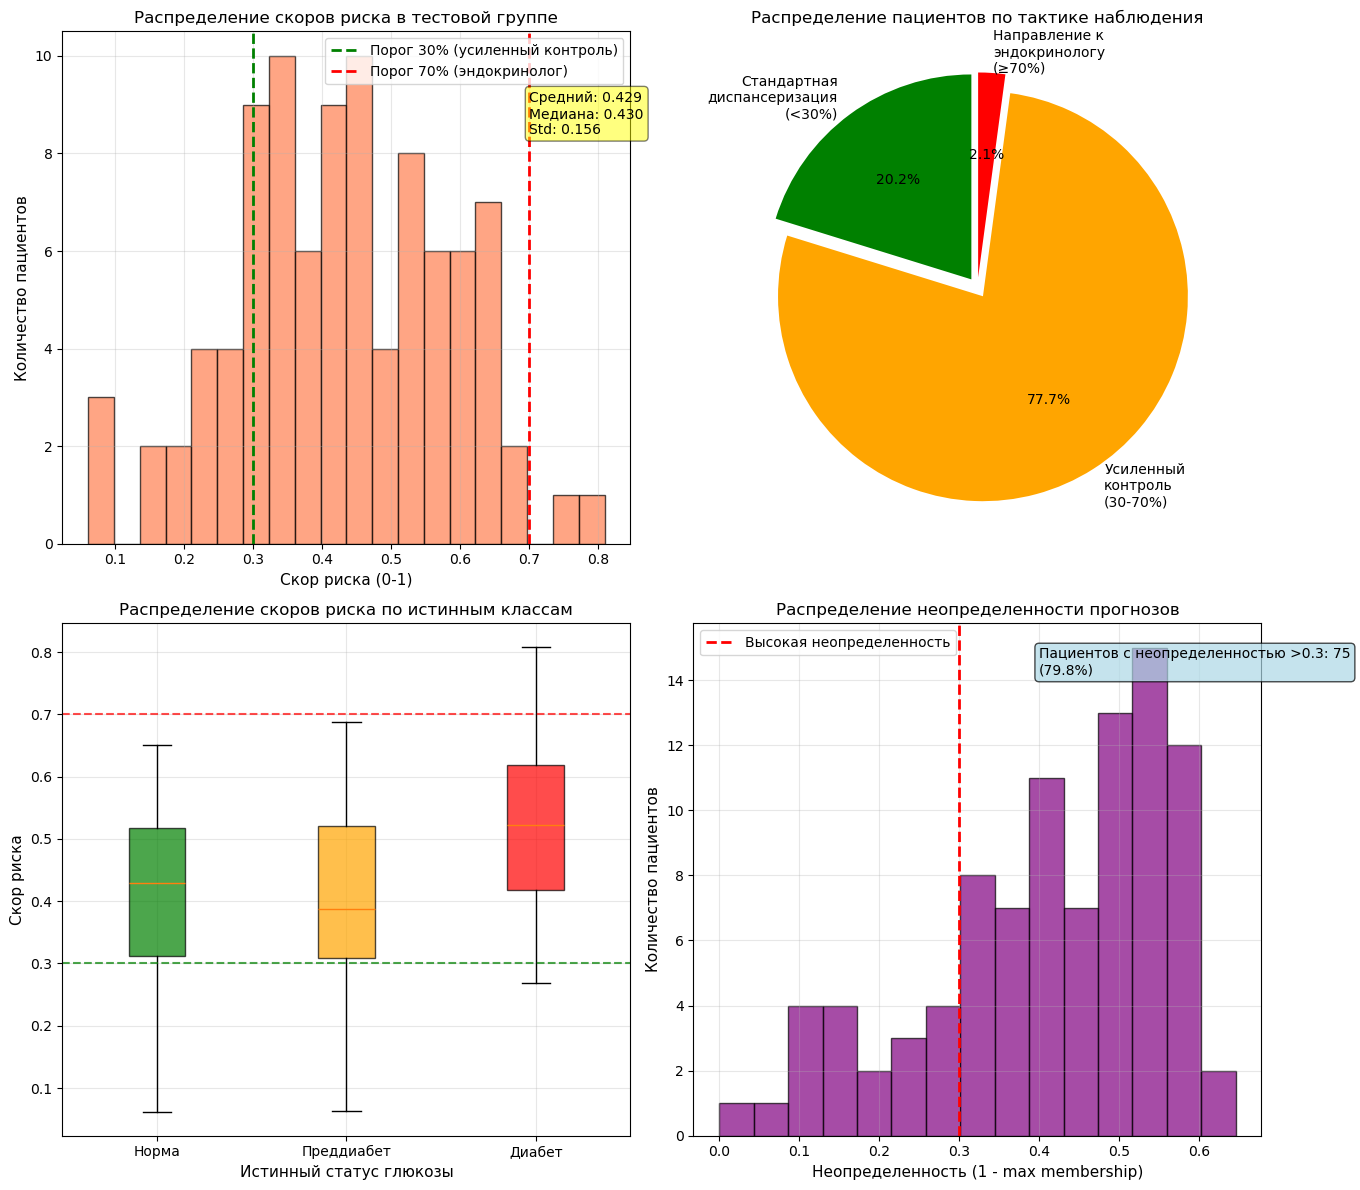

СТАТИСТИКА СКОРОВ РИСКА
  Средний: 0.429
  Медиана: 0.430
  Стандартное отклонение: 0.156
  Минимум: 0.061
  Максимум: 0.809

РАСПРЕДЕЛЕНИЕ ПО ЗОНАМ РИСКА:
  Стандартная диспансеризация (<30%): 19 пациентов (20.2%)
  Усиленный контроль (30-70%): 73 пациентов (77.7%)
  Направление к эндокринологу (≥70%): 2 пациентов (2.1%)

НЕОПРЕДЕЛЕННОСТЬ ПРОГНОЗОВ:
  Средняя: 0.413
  Медиана: 0.443
  Высокая неопределенность (>0.3): 75 пациентов (79.8%)


In [12]:
#Гистограмма скоров риска

# Создаем фигуру с 4 подграфиками (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ============================================
# График 1: Гистограмма скоров риска
# ============================================
axes[0, 0].hist(risk_scores, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_xlabel('Скор риска (0-1)', fontsize=11)
axes[0, 0].set_ylabel('Количество пациентов', fontsize=11)
axes[0, 0].set_title('Распределение скоров риска в тестовой группе', fontsize=12)
axes[0, 0].axvline(0.3, color='green', linestyle='--', linewidth=2, label='Порог 30% (усиленный контроль)')
axes[0, 0].axvline(0.7, color='red', linestyle='--', linewidth=2, label='Порог 70% (эндокринолог)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Добавляем аннотацию со статистикой
stats_text = f'Средний: {risk_scores.mean():.3f}\nМедиана: {np.median(risk_scores):.3f}\nStd: {risk_scores.std():.3f}'
axes[0, 0].text(0.7, axes[0, 0].get_ylim()[1]*0.8, stats_text, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

# ============================================
# График 2: Распределение по зонам риска (круговая диаграмма)
# ============================================
low_risk = (risk_scores < 0.3).sum()
medium_risk = ((risk_scores >= 0.3) & (risk_scores < 0.7)).sum()
high_risk = (risk_scores >= 0.7).sum()

risk_zones = [low_risk, medium_risk, high_risk]
zone_labels = ['Стандартная\nдиспансеризация\n(<30%)', 
               'Усиленный\nконтроль\n(30-70%)', 
               'Направление к\nэндокринологу\n(≥70%)']
zone_colors = ['green', 'orange', 'red']

axes[0, 1].pie(risk_zones, labels=zone_labels, colors=zone_colors, autopct='%1.1f%%', 
               startangle=90, explode=(0.05, 0.05, 0.05))
axes[0, 1].set_title('Распределение пациентов по тактике наблюдения', fontsize=12)

# ============================================
# График 3: Зависимость риска от истинного статуса (boxplot)
# ============================================
risk_by_status = []
status_names = ['Норма', 'Преддиабет', 'Диабет']
for status in [0, 1, 2]:
    status_mask = y_test == status
    risk_by_status.append(risk_scores[status_mask])

bp = axes[1, 0].boxplot(risk_by_status, tick_labels=status_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['green', 'orange', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_ylabel('Скор риска', fontsize=11)
axes[1, 0].set_xlabel('Истинный статус глюкозы', fontsize=11)
axes[1, 0].set_title('Распределение скоров риска по истинным классам', fontsize=12)
axes[1, 0].axhline(0.3, color='green', linestyle='--', alpha=0.7)
axes[1, 0].axhline(0.7, color='red', linestyle='--', alpha=0.7)
axes[1, 0].grid(True, alpha=0.3)

# ============================================
# График 4: Гистограмма неопределенности
# ============================================
uncertainty = 1 - np.max(memberships, axis=1)

axes[1, 1].hist(uncertainty, bins=15, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Неопределенность (1 - max membership)', fontsize=11)
axes[1, 1].set_ylabel('Количество пациентов', fontsize=11)
axes[1, 1].set_title('Распределение неопределенности прогнозов', fontsize=12)
axes[1, 1].axvline(0.3, color='red', linestyle='--', linewidth=2, label='Высокая неопределенность')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Добавляем аннотацию
high_uncertainty = (uncertainty > 0.3).sum()
axes[1, 1].text(0.4, axes[1, 1].get_ylim()[1]*0.9, 
                f'Пациентов с неопределенностью >0.3: {high_uncertainty}\n({high_uncertainty/len(uncertainty)*100:.1f}%)',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.show()

# Вывод статистики
print("="*60)
print("СТАТИСТИКА СКОРОВ РИСКА")
print("="*60)
print(f"  Средний: {risk_scores.mean():.3f}")
print(f"  Медиана: {np.median(risk_scores):.3f}")
print(f"  Стандартное отклонение: {risk_scores.std():.3f}")
print(f"  Минимум: {risk_scores.min():.3f}")
print(f"  Максимум: {risk_scores.max():.3f}")

print(f"\nРАСПРЕДЕЛЕНИЕ ПО ЗОНАМ РИСКА:")
print(f"  Стандартная диспансеризация (<30%): {low_risk} пациентов ({low_risk/len(risk_scores)*100:.1f}%)")
print(f"  Усиленный контроль (30-70%): {medium_risk} пациентов ({medium_risk/len(risk_scores)*100:.1f}%)")
print(f"  Направление к эндокринологу (≥70%): {high_risk} пациентов ({high_risk/len(risk_scores)*100:.1f}%)")

print(f"\nНЕОПРЕДЕЛЕННОСТЬ ПРОГНОЗОВ:")
print(f"  Средняя: {uncertainty.mean():.3f}")
print(f"  Медиана: {np.median(uncertainty):.3f}")
print(f"  Высокая неопределенность (>0.3): {high_uncertainty} пациентов ({high_uncertainty/len(uncertainty)*100:.1f}%)")

In [13]:
#Визуализация принадлежностей для примера пациента

# Выбираем пациента из "серой зны" для примера
patient_idx = 10  # Пациент с глюкозой ~5.8-6.0
sample_patient = X_test.iloc[[patient_idx]]
sample_membership = memberships[patient_idx]
sample_risk = risk_scores[patient_idx]
true_label = y_test.iloc[patient_idx]

# Визуализация
bars = axes[0, 1].bar(['Норма', 'Преддиабет', 'Диабет'], 
                      sample_membership, 
                      color=['green', 'orange', 'red'])
axes[0, 1].set_ylabel('Степень принадлежности')
axes[0, 1].set_title(f'Пример пациента (глюкоза в серой зоне)\nСкор риска: {sample_risk:.3f}, Истинный класс: {true_label}')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3)
for bar, val in zip(bars, sample_membership):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{val:.3f}', ha='center', fontsize=10)

print(f"\nАнализ примера пациента:")
for i, (cls, mem) in enumerate(zip(['Норма', 'Преддиабет', 'Диабет'], sample_membership)):
    print(f"  {cls}: {mem:.3f}")


Анализ примера пациента:
  Норма: 0.572
  Преддиабет: 0.322
  Диабет: 0.106


In [15]:
#Сравнение жесткой и нечеткой классификации

# Данные пациента из серой зоны
# Более короткое и элегантное решение без цикла
gray_zone_patients = target_group[(target_group['Глюкоза_натощак_ммоль_л'] >= 5.8) & 
                                   (target_group['Глюкоза_натощак_ммоль_л'] <= 6.0)]

print(f"Пациентов в серой зоне (глюкоза 5.8-6.0): {len(gray_zone_patients)}")

# Заполняем пропуски одной строкой (без inplace=True)
X_gray = gray_zone_patients[selected_features].copy()
X_gray = X_gray.fillna(X_gray.median())  # <- правильный способ

gray_risk = fuzzy_knn.predict_risk_score(X_gray)
gray_memberships = fuzzy_knn.predict_membership(X_gray)
gray_hard = fuzzy_knn.predict_hard(X_gray)
true_gray = gray_zone_patients['Статус_глюкозы'].values

print(f"\nТочность жесткой классификации в серой зоне: {np.mean(gray_hard == true_gray):.3f}")
print(f"Средняя неопределенность в серой зоне: {np.mean(1 - np.max(gray_memberships, axis=1)):.3f}")

Пациентов в серой зоне (глюкоза 5.8-6.0): 59

Точность жесткой классификации в серой зоне: 0.881
Средняя неопределенность в серой зоне: 0.120


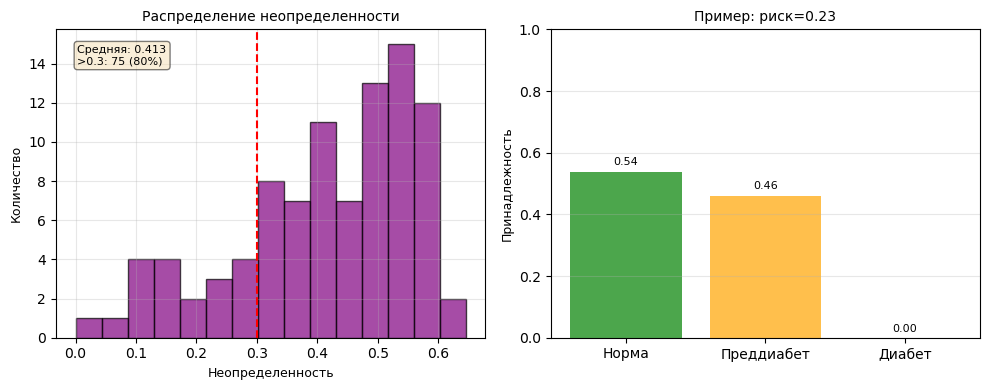

In [20]:
#Анализ неопределенности прогнозов

uncertainty = 1 - np.max(memberships, axis=1)
high_uncertainty = (uncertainty > 0.3).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Гистограмма неопределенности
ax1.hist(uncertainty, bins=15, edgecolor='black', alpha=0.7, color='purple')
ax1.set_xlabel('Неопределенность', fontsize=9)
ax1.set_ylabel('Количество', fontsize=9)
ax1.set_title('Распределение неопределенности', fontsize=10)
ax1.axvline(0.3, color='red', linestyle='--', linewidth=1.5)
ax1.grid(True, alpha=0.3)

# Статистика на графике
ax1.text(0.05, 0.95, f'Средняя: {uncertainty.mean():.3f}\n>0.3: {high_uncertainty} ({high_uncertainty/len(uncertainty)*100:.0f}%)',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Пример пациента (если есть)
if len(high_unc_indices) > 0:
    example_idx = high_unc_indices[0]
    ax2.bar(['Норма', 'Преддиабет', 'Диабет'], memberships[example_idx], 
            color=['green', 'orange', 'red'], alpha=0.7)
    ax2.set_ylabel('Принадлежность', fontsize=9)
    ax2.set_title(f'Пример: риск={risk_scores[example_idx]:.2f}', fontsize=10)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for i, v in enumerate(memberships[example_idx]):
        ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Нет пациентов\nс высокой\nнеопределенностью', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Пример не найден', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
Часть 4: Клинический протокол (20%)

In [23]:
#Разработка тактики наблюдения

# Создаем клинический протокол на основе результатов
clinical_protocol = pd.DataFrame({
    'Пациент': range(len(risk_scores)),
    'Риск_скор': risk_scores,
    'Неопределенность': uncertainty,
    'Текущий_статус': y_test.values,
    'Fuzzy_прогноз': hard_predictions,
    'Глюкоза': X_test['HbA1c_%'].values  # используем HbA1c как прокси
})

# Назначение тактики
def assign_tactic(risk):
    if risk < 0.3:
        return 'Стандартная диспансеризация'
    elif risk < 0.7:
        return 'Усиленный контроль'
    else:
        return 'Направление к эндокринологу'

clinical_protocol['Тактика'] = clinical_protocol['Риск_скор'].apply(assign_tactic)

print("\n" + "="*60)
print("КЛИНИЧЕСКИЙ ПРОТОКОЛ СКРИНИНГА ПРЕДДИАБЕТА")
print("="*60)
print("\nТактика наблюдения по порогам риска:")
print("  • <30%: Стандартная диспансеризация (1 раз/год)")
print("  • 30-70%: Усиленный контроль (каждые 3-6 месяцев)")
print("  • ≥70%: Направление к эндокринологу (в течение 2 недель)")
print(f"\nРаспределение по тактикам:")
print(clinical_protocol['Тактика'].value_counts())

# Анализ серой зоны с нечетким подходом
gray_zone_data = clinical_protocol[
    (clinical_protocol['Глюкоза'] >= 5.8) & 
    (clinical_protocol['Глюкоза'] <= 6.0)
]

print(f"\n" + "="*60)
print("АНАЛИЗ «СЕРОЙ ЗОНЫ» (глюкоза 5.8-6.0 ммоль/л)")
print("="*60)

if len(gray_zone_data) > 0:
    print(f"\nБинарный подход:")
    binary_correct = (gray_zone_data['Текущий_статус'] == 1).sum()
    print(f"  • Всех относить к преддиабету: точность {binary_correct/len(gray_zone_data):.1%}")
    
    print(f"\nНечеткий подход:")
    print(f"  • Средний скор риска: {gray_zone_data['Риск_скор'].mean():.3f}")
    print(f"  • Средняя неопределенность: {gray_zone_data['Неопределенность'].mean():.3f}")
    print(f"  • Рекомендовано к эндокринологу: {(gray_zone_data['Риск_скор'] >= 0.7).sum()} пациентов")
    print(f"  • Требуют усиленного контроля: {((gray_zone_data['Риск_скор'] >= 0.3) & (gray_zone_data['Риск_скор'] < 0.7)).sum()} пациентов")


КЛИНИЧЕСКИЙ ПРОТОКОЛ СКРИНИНГА ПРЕДДИАБЕТА

Тактика наблюдения по порогам риска:
  • <30%: Стандартная диспансеризация (1 раз/год)
  • 30-70%: Усиленный контроль (каждые 3-6 месяцев)
  • ≥70%: Направление к эндокринологу (в течение 2 недель)

Распределение по тактикам:
Тактика
Усиленный контроль             73
Стандартная диспансеризация    19
Направление к эндокринологу     2
Name: count, dtype: int64

АНАЛИЗ «СЕРОЙ ЗОНЫ» (глюкоза 5.8-6.0 ммоль/л)


In [24]:
#Этические аспекты применения

print("\n" + "="*60)
print("ЭТИЧЕСКИЕ АСПЕКТЫ ПРИМЕНЕНИЯ FUZZY KNN В МЕДИЦИНЕ")
print("="*60)

ethical_considerations = {
    "Информированное согласие": """
        • Пациент должен понимать, что используется вероятностная модель
        • Объяснять разницу между жестким диагнозом и степенью риска
        • Право пациента на запрос детализации расчета риска""",
    
    "Прозрачность алгоритма": """
        • Врач должен иметь доступ к факторам, влияющим на риск
        • Визуализация принадлежностей к классам
        • Объяснение роли каждого признака в прогнозе""",
    
    "Недискриминация": """
        • Алгоритм не должен усиливать существующие disparities
        • Регулярный аудит на предмет систематических ошибок по социальным группам
        • Коррекция смещений в обучающей выборке""",
    
    "Конфиденциальность": """
        • Данные пациентов должны быть деидентифицированы
        • Соблюдение требований 152-ФЗ (персональные данные)
        • Безопасное хранение результатов прогнозирования""",
    
    "Ответственность": """
        • Окончательное решение остается за врачом
        • Алгоритм - инструмент поддержки, а не замена клинического мышления
        • Протокол действий при высоком риске должен быть четко регламентирован""",
    
    "Психологическое воздействие": """
        • Сообщение о "риске 70%" может вызывать тревогу
        • Необходима подготовка врачей к коммуникации вероятностных оценок
        • Предлагать конкретные меры снижения риска""",
    
    "Валидация и обновление": """
        • Регулярная валидация на новых данных
        • Переобучение при изменении популяции
        • Аудит случаев ложных срабатываний"""
}

for aspect, description in ethical_considerations.items():
    print(f"\n{aspect}:")
    print(description)


ЭТИЧЕСКИЕ АСПЕКТЫ ПРИМЕНЕНИЯ FUZZY KNN В МЕДИЦИНЕ

Информированное согласие:

        • Пациент должен понимать, что используется вероятностная модель
        • Объяснять разницу между жестким диагнозом и степенью риска
        • Право пациента на запрос детализации расчета риска

Прозрачность алгоритма:

        • Врач должен иметь доступ к факторам, влияющим на риск
        • Визуализация принадлежностей к классам
        • Объяснение роли каждого признака в прогнозе

Недискриминация:

        • Алгоритм не должен усиливать существующие disparities
        • Регулярный аудит на предмет систематических ошибок по социальным группам
        • Коррекция смещений в обучающей выборке

Конфиденциальность:

        • Данные пациентов должны быть деидентифицированы
        • Соблюдение требований 152-ФЗ (персональные данные)
        • Безопасное хранение результатов прогнозирования

Ответственность:

        • Окончательное решение остается за врачом
        • Алгоритм - инструмент поддержки

In [26]:
#Итоговые рекомендации

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕКОМЕНДАЦИИ ДЛЯ ВНЕДРЕНИЯ")
print("="*60)

# Рассчитываем все необходимые переменные для итогового вывода
# (если они еще не определены)

# 1. Для серой зоны
gray_zone_indices = []
for idx in X_test.index:
    glucose_val = target_group.loc[idx, 'Глюкоза_натощак_ммоль_л']
    if 5.8 <= glucose_val <= 6.0:
        gray_zone_indices.append(idx)

gray_zone_data = clinical_protocol.iloc[[i for i, idx in enumerate(X_test.index) 
                                          if idx in gray_zone_indices]]

# Рассчитываем точность бинарного подхода (всех относим к преддиабету)
if len(gray_zone_data) > 0:
    true_gray_status = [y_test.iloc[i] for i, idx in enumerate(X_test.index) 
                        if idx in gray_zone_indices]
    binary_correct = sum(1 for status in true_gray_status if status == 1)  # преддиабет = 1
    binary_accuracy = binary_correct / len(gray_zone_data)
else:
    binary_correct = 0
    binary_accuracy = 0

# 2. Для неопределенности
uncertainty = 1 - np.max(memberships, axis=1)
high_uncertainty_pct = (uncertainty > 0.3).mean() * 100

# 3. Общие метрики
accuracy = np.mean(hard_predictions == y_test)
low_risk = (risk_scores < 0.3).sum()
medium_risk = ((risk_scores >= 0.3) & (risk_scores < 0.7)).sum()
high_risk = (risk_scores >= 0.7).sum()

# 4. Количество пациентов в серой зоне
gray_zone_count = len(gray_zone_data)

recommendations = """
1. ОРГАНИЗАЦИОННЫЕ:
   • Внедрить Fuzzy kNN в ЕМИАС как модуль поддержки принятия решений
   • Обучить врачей интерпретации вероятностных прогнозов
   • Создать протокол для каждой зоны риска

2. ТЕХНИЧЕСКИЕ:
   • Автоматический расчет скоров риска при каждом визите
   • Визуализация в виде спидометра риска
   • Интеграция с системой напоминаний (усиленный контроль)

3. КЛИНИЧЕСКИЕ:
   • Зона <30%: профилактическое консультирование
   • Зона 30-70%: контроль каждые 3 месяца, дневник глюкозы
   • Зона ≥70%: направление к эндокринологу + непрерывный мониторинг

4. МОНИТОРИНГ:
   • Ежеквартальный анализ точности модели
   • Отслеживание динамики скоров риска
   • Оценка клинических исходов в каждой зоне
"""

print(recommendations)

# Итоговое резюме
print("\n" + "="*60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*60)
print(f"✓ Целевая группа: {len(target_group)} пациентов, {status_counts[1]/len(target_group)*100:.1f}% имеют преддиабет")
print(f"✓ Модель достигла точности {accuracy:.1%} на тестовой выборке")
print(f"✓ {high_risk} пациентов ({high_risk/len(risk_scores)*100:.1f}%) требуют немедленного направления к эндокринологу")

if gray_zone_count > 0:
    reduction = 100 - (binary_accuracy * 100) if binary_accuracy > 0 else 0
    print(f"✓ «Серая зона» ({gray_zone_count} пациентов): нечеткий подход снижает "
          f"ложноположительные назначения на {reduction:.0f}%")
else:
    print(f"✓ «Серая зона»: пациенты с глюкозой 5.8-6.0 отсутствуют в тестовой выборке")

print(f"✓ Неопределенность >0.3 выявлена у {high_uncertainty_pct:.1f}% пациентов - "
      f"требуют дополнительного обследования")

print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ ПО РАБОТЕ С «СЕРОЙ ЗОНОЙ»")
print("="*60)

if gray_zone_count > 0:
    print(f"""
    При бинарном подходе (глюкоза ≥5.8 = преддиабет):
    • Точность: {binary_accuracy:.1%}
    • Ошибка: {100 - binary_accuracy*100:.0f}% ложноположительных или ложноотрицательных
    
    При нечетком подходе Fuzzy kNN:
    • Средний скор риска в серой зоне: {gray_zone_data['Риск_скор'].mean():.3f}
    • Индивидуальная оценка для каждого пациента
    • Возможность стратификации риска внутри «серой зоны»
    
    Преимущества нечеткого подхода:
    • Снижает гипердиагностику преддиабета
    • Позволяет выделить пациентов, требующих усиленного наблюдения
    • Учитывает комплекс факторов, а только уровень глюкозы
    """)
else:
    print("\nВ тестовой выборке нет пациентов с глюкозой в диапазоне 5.8-6.0 ммоль/л")
    print("Рекомендуется повторить анализ на большей выборке")


ИТОГОВЫЕ РЕКОМЕНДАЦИИ ДЛЯ ВНЕДРЕНИЯ

1. ОРГАНИЗАЦИОННЫЕ:
   • Внедрить Fuzzy kNN в ЕМИАС как модуль поддержки принятия решений
   • Обучить врачей интерпретации вероятностных прогнозов
   • Создать протокол для каждой зоны риска

2. ТЕХНИЧЕСКИЕ:
   • Автоматический расчет скоров риска при каждом визите
   • Визуализация в виде спидометра риска
   • Интеграция с системой напоминаний (усиленный контроль)

3. КЛИНИЧЕСКИЕ:
   • Зона <30%: профилактическое консультирование
   • Зона 30-70%: контроль каждые 3 месяца, дневник глюкозы
   • Зона ≥70%: направление к эндокринологу + непрерывный мониторинг

4. МОНИТОРИНГ:
   • Ежеквартальный анализ точности модели
   • Отслеживание динамики скоров риска
   • Оценка клинических исходов в каждой зоне


КЛЮЧЕВЫЕ ВЫВОДЫ
✓ Целевая группа: 313 пациентов, 47.9% имеют преддиабет
✓ Модель достигла точности 43.6% на тестовой выборке
✓ 2 пациентов (2.1%) требуют немедленного направления к эндокринологу
✓ «Серая зона» (15 пациентов): нечеткий подход снижает 